# Wind-Price Spread Arbitrage — DK1 & DK2 Power Markets

See README.md for full methodology, theory, and results.

Data: ENTSO-E (prices + wind actual) · EDS (consumption + post-2025 prices)

In [1]:
import warnings, requests, time
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
from entsoe import EntsoePandasClient

In [2]:
warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f9f9f9',
    'axes.grid': True, 'grid.alpha': 0.35,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'font.size': 10,
})

In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
ENTSOE_KEY    = '225b44d1-41a9-4d68-ae60-0c5444cd1b15'
DK1           = '10YDK-1--------W'
DK2           = '10YDK-2--------M'
EDS_BASE      = "https://api.energidataservice.dk/dataset"

FULL_START    = "2019-01-01"
FULL_END      = pd.Timestamp.now(tz="UTC").strftime("%Y-%m-%d")
HOLDOUT_START = "2026-01-01"
PRICE_CUTOFF  = "2025-10-01"

TRAIN_YEARS   = 2
TEST_MONTHS   = 6
STEP_MONTHS   = 6

ENTRY_Z       = 2.0
EXIT_Z        = 0.5
POSITION_MW   = 1.0
ENTRY_COST    = 1.0
EXIT_COST     = 1.0
HOLD_COST     = 1.5

PENETRATION_WINDOW = 4380   # 6-month rolling window for penetration threshold
PRICE_WINDOW       = 4380   # 6-month rolling window for price threshold
SURPRISE_WIN       = 168    # 7-day rolling window for wind surprise baseline
PENETRATION_PCT    = 60     # "high wind penetration" = above rolling 60th pctile
COST_SWEEP         = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

STRATEGIES    = ['all', 'penetration', 'price', 'hc']

client = EntsoePandasClient(api_key=ENTSOE_KEY)

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def fetch_entsoe(fn, start: str, end: str, label: str = "") -> pd.Series:
    """
    Fetch one ENTSO-E series in yearly chunks with automatic retry.
    - Max 3 parallel requests (ENTSO-E blocks aggressive parallelism)
    - Retries up to 3 times on 503/429 with increasing wait (10s, 20s, 30s)
    - 503 = server overloaded (common); 429 = rate limited
    """
    tz = "Europe/Copenhagen"
    s, e = pd.Timestamp(start, tz=tz), pd.Timestamp(end, tz=tz)
    chunks = [(max(pd.Timestamp(f"{yr}-01-01", tz=tz), s),
               min(pd.Timestamp(f"{yr+1}-01-01", tz=tz), e))
              for yr in range(s.year, e.year + 1)
              if max(pd.Timestamp(f"{yr}-01-01", tz=tz), s)
               < min(pd.Timestamp(f"{yr+1}-01-01", tz=tz), e)]

    def fetch_one(cs, ce):
        for attempt in range(3):
            try:
                chunk = fn(cs, ce)
                if chunk is not None and len(chunk) > 0:
                    return cs.year, (chunk.sum(axis=1)
                                     if isinstance(chunk, pd.DataFrame) else chunk)
                return cs.year, None
            except Exception as ex:
                msg = str(ex)
                if '503' in msg or '429' in msg:
                    time.sleep(10 * (attempt + 1))   # 10s → 20s → 30s
                else:
                    print(f"     ⚠ {label} {cs.date()}→{ce.date()}: {msg[:80]}")
                    return cs.year, None
        print(f"     ⚠ {label} {cs.date()}→{ce.date()}: failed after 3 attempts")
        return cs.year, None

    results = {}
    with ThreadPoolExecutor(max_workers=3) as pool:   # 3 max — avoids rate limits
        for yr, chunk in [f.result() for f in
                          [pool.submit(fetch_one, cs, ce) for cs, ce in chunks]]:
            if chunk is not None:
                results[yr] = chunk

    if not results:
        return pd.Series(dtype=float)
    out = pd.concat(results.values()).sort_index()
    out = out[~out.index.duplicated(keep='first')]
    return out.resample("h").mean()


def to_utc_hourly(s: pd.Series) -> pd.Series:
    """Normalise any Series to UTC hourly DatetimeIndex."""
    if s is None or len(s) == 0:
        return pd.Series(dtype=float)
    idx = pd.to_datetime(s.index)
    idx = idx.tz_localize("UTC") if idx.tz is None else idx.tz_convert("UTC")
    s = s.copy()
    s.index = idx
    return s[~s.index.duplicated(keep='first')].resample("h").mean()


def fetch_eds_settlement(zone: str, start: str, end: str) -> pd.DataFrame:
    """
    Fetch ProductionConsumptionSettlement from EDS for a given zone.
    Returns a DataFrame with GrossConsumptionMWh for the penetration ratio.
    """
    col = "GrossConsumptionMWh"

    chunks = []
    cur = pd.Timestamp(start)
    while cur < pd.Timestamp(end):
        chunk_end = min(cur + pd.DateOffset(years=1), pd.Timestamp(end))
        r = requests.get(f"{EDS_BASE}/ProductionConsumptionSettlement", params={
            "start":   cur.strftime("%Y-%m-%dT00:00"),
            "end":     chunk_end.strftime("%Y-%m-%dT00:00"),
            "filter":  f'{{"PriceArea":["{zone}"]}}',
            "columns": f"HourUTC,{col}",
            "sort":    "HourUTC asc", "limit": 0,
        }, timeout=120)
        recs = r.json().get("records", [])
        if recs:
            chunks.append(pd.DataFrame(recs))
        cur = chunk_end

    if not chunks:
        return pd.DataFrame()

    df = pd.concat(chunks, ignore_index=True)
    df["HourUTC"] = pd.to_datetime(df["HourUTC"], utc=True)
    df = df.set_index("HourUTC").sort_index()
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.resample("h").mean()
    return df


def fetch_eds_prices(start: str, end: str, zone: str = "DK1") -> pd.Series:
    """Fetch post-Oct 2025 quarter-hourly prices from EDS, resampled to hourly."""
    chunks = []
    cur = pd.Timestamp(start)
    while cur < pd.Timestamp(end):
        chunk_end = min(cur + pd.DateOffset(months=6), pd.Timestamp(end))
        r = requests.get(f"{EDS_BASE}/DayAheadPrices", params={
            "start":  cur.strftime("%Y-%m-%dT00:00"),
            "end":    chunk_end.strftime("%Y-%m-%dT00:00"),
            "filter": f'{{"PriceArea":["{zone}"]}}',
            "sort":   "TimeUTC asc", "limit": 0,
        }, timeout=60)
        recs = r.json().get("records", [])
        if recs:
            chunks.append(pd.DataFrame(recs))
        cur = chunk_end
    if not chunks:
        return pd.Series(dtype=float)
    ep = pd.concat(chunks, ignore_index=True)
    ep["TimeUTC"] = pd.to_datetime(ep["TimeUTC"], utc=True)
    return ep.set_index("TimeUTC")["DayAheadPriceEUR"].resample("h").mean()


def build_wind_surprise(wind_act: pd.Series) -> pd.Series:
    """
    Wind surprise = actual wind − 7-day rolling seasonal baseline.
    Baseline = rolling 168-hour mean (same hour-of-day pattern emerges
    naturally from the rolling window since wind is diurnal).
    Captures unexpected wind deviations — what the auction could not price.
    """
    baseline = wind_act.rolling(SURPRISE_WIN, min_periods=SURPRISE_WIN // 2).mean()
    return wind_act - baseline


def build_dataset(zone: str, zone_label: str) -> pd.DataFrame:
    """
    Fetch and assemble all data for one bidding zone.

    Data sources:
      ENTSO-E: day-ahead prices (up to Oct 2025) + wind actual (B18+B19, full period)
      EDS ProductionConsumptionSettlement: gross consumption (for penetration ratio)
      EDS DayAheadPrices: post-Oct 2025 prices (quarter-hourly → hourly mean)

    Regime variables (both computed from data we already have):
      wind_penetration = wind_act / gross_consumption
        High penetration → grid cannot absorb wind → larger price drops
      price_high = price > 6-month rolling median
        Proxy for expensive-gas environment → stronger merit-order effect
    """
    print(f"\n{'='*65}")
    print(f"  FETCHING: {zone_label}  |  {FULL_START} → {FULL_END}")
    print(f"{'='*65}")

    def _wind(psr_types, query_fn):
        def fn(s, e):
            parts = [query_fn(zone, start=s, end=e, psr_type=p)
                     for p in psr_types]
            parts = [p.sum(axis=1) if isinstance(p, pd.DataFrame) else p
                     for p in parts if p is not None and len(p) > 0]
            if not parts: return None
            r = pd.concat(parts)
            return r.groupby(r.index).sum()
        return fn

    # ── ENTSO-E: prices and wind actual in parallel ───────────────────────────
    entsoe_end = min(FULL_END, PRICE_CUTOFF)
    print(f"  Fetching ENTSO-E (prices + wind)...")
    fetched = {}
    series_defs = {
        "prices":   (lambda s,e: client.query_day_ahead_prices(zone, start=s, end=e),
                     FULL_START, entsoe_end),
        "wind_act": (_wind(['B18','B19'], client.query_generation),
                     FULL_START, FULL_END),
    }
    with ThreadPoolExecutor(max_workers=2) as pool:
        futures = {pool.submit(fetch_entsoe, fn, s, e, lbl): lbl
                   for lbl, (fn, s, e) in series_defs.items()}
        for fut in as_completed(futures):
            lbl = futures[fut]
            fetched[lbl] = fut.result()
            print(f"     {'✓' if len(fetched[lbl])>0 else '✗'} "
                  f"{lbl}: {len(fetched[lbl]):,} obs")

    # ── EDS: gross consumption (for penetration ratio) ────────────────────────
    # penetration = wind_act / demand — demand comes from EDS settlement data
    print(f"  Fetching EDS gross consumption (for penetration ratio)...")
    eds_settlement = fetch_eds_settlement(zone_label, FULL_START, FULL_END)
    if len(eds_settlement) > 0:
        eds_demand = eds_settlement['GrossConsumptionMWh']
        print(f"     ✓ EDS settlement: {len(eds_settlement):,} obs | "
              f"avg demand {eds_demand.mean():.0f} MWh/h")
    else:
        print(f"     ✗ EDS settlement unavailable — penetration regime disabled")
        eds_demand = pd.Series(dtype=float)

    # ── EDS: post-Oct 2025 prices ─────────────────────────────────────────────
    if FULL_END > PRICE_CUTOFF:
        print(f"  Fetching EDS post-Oct 2025 prices...")
        eds_p = fetch_eds_prices(PRICE_CUTOFF, FULL_END, zone_label)
        if len(eds_p) > 0:
            eds_p.index = eds_p.index.tz_convert("Europe/Copenhagen")
            fetched["prices"] = pd.concat([fetched["prices"], eds_p])
            fetched["prices"] = fetched["prices"][
                ~fetched["prices"].index.duplicated(keep='first')]
            print(f"     ✓ Combined prices: {len(fetched['prices']):,} obs")

    # ── Normalise and join ────────────────────────────────────────────────────
    prices_s = to_utc_hourly(fetched.get("prices", pd.Series(dtype=float)))
    wind_act  = to_utc_hourly(fetched.get("wind_act", pd.Series(dtype=float)))
    demand    = to_utc_hourly(eds_demand)

    df = pd.DataFrame({'price': prices_s, 'wind_act': wind_act, 'demand': demand})
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, utc=True)

    # QC
    df = df.dropna(subset=['price', 'wind_act'])
    df = df[df['price'].between(-500, 3000) & (df['wind_act'] >= 0)]
    df = df.resample("h").mean()
    df['demand'] = df['demand'].ffill()

    # ── Wind surprise signal ──────────────────────────────────────────────────
    df['wind_surprise'] = build_wind_surprise(df['wind_act'])

    # ── Wind penetration regime ───────────────────────────────────────────────
    # penetration = wind_act / gross_consumption (0–1 or higher in export surplus)
    # High penetration → wind competing with itself → large price drops
    # Rolling 60th percentile threshold adapts as capacity grows over time
    if df['demand'].notna().sum() > 1000:
        df['penetration'] = (df['wind_act'] / df['demand'].clip(lower=1)).clip(0, 2)
        pct_threshold     = df['penetration'].rolling(
            PENETRATION_WINDOW, min_periods=720).quantile(PENETRATION_PCT / 100)
        df['pen_high']    = (df['penetration'] >= pct_threshold).astype(int)
        print(f"     Wind penetration: mean={df['penetration'].mean()*100:.1f}% | "
              f"pen_high={df['pen_high'].mean()*100:.1f}% of hours")
    else:
        # Fallback if demand data unavailable: use wind absolute level
        df['penetration'] = df['wind_act']
        pct_threshold     = df['penetration'].rolling(
            PENETRATION_WINDOW, min_periods=720).quantile(PENETRATION_PCT / 100)
        df['pen_high']    = (df['penetration'] >= pct_threshold).astype(int)
        print(f"     ⚠ Demand unavailable — using wind level as penetration proxy")
        print(f"     pen_high={df['pen_high'].mean()*100:.1f}% of hours")

    # ── Price-level regime ────────────────────────────────────────────────────
    df['price_median'] = df['price'].rolling(PRICE_WINDOW, min_periods=720).median()
    df['price_high']   = (df['price'] > df['price_median']).astype(int)

    # ── High-confidence: BOTH penetration high AND price high ─────────────────
    df['hc_regime'] = ((df['pen_high'] == 1) & (df['price_high'] == 1)).astype(int)

    df_out = df[df.index >= FULL_START].copy()
    print(f"\n  {len(df_out):,} obs | {df_out.index[0].date()} → {df_out.index[-1].date()}")
    print(f"  pen_high:  {df_out['pen_high'].mean()*100:.1f}%  |  "
          f"price_high: {df_out['price_high'].mean()*100:.1f}%  |  "
          f"HC: {df_out['hc_regime'].mean()*100:.1f}%")
    return df_out

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def fit_model(df_train: pd.DataFrame) -> dict:
    """
    Fit base OLS and interaction model on training window.

    BASE: P_t = β₀ + α·W_actual + γ·W_surprise + ε_t
      α: merit-order coefficient (expected negative)
      γ: surprise coefficient (expected negative — unexpected wind depresses
         prices beyond the level effect)

    INTERACTION: P_t = β₀ + α₀·W + α₁·(W×penetration) + α₂·(W×price_high) + ε_t
      penetration is continuous (0–2) so the interaction varies smoothly.
      Expected: α₁ < 0 (high penetration amplifies wind's price impact)
                α₂ < 0 (high price amplifies wind's displacement value)

    HAC standard errors (24 lags) for hourly autocorrelation.
    """
    cols  = ['price', 'wind_act', 'wind_surprise', 'penetration', 'price_high']
    clean = df_train[cols].replace([np.inf, -np.inf], np.nan).dropna()

    # Base model
    X     = sm.add_constant(clean[['wind_act', 'wind_surprise']])
    ols   = sm.OLS(clean['price'], X).fit(cov_type='HAC', cov_kwds={'maxlags': 24})
    alpha = ols.params['wind_act']
    gamma = ols.params.get('wind_surprise', 0.0)

    spread = clean['price'] - alpha*clean['wind_act'] - gamma*clean['wind_surprise']
    s      = spread.dropna()
    phi    = np.corrcoef(s.iloc[:-1].values, s.iloc[1:].values)[0, 1]

    # Engle-Granger cointegration test — verifies wind and price share a
    # long-run equilibrium. p < 0.05 confirms the spread is mean-reverting
    # and the strategy has a statistical foundation in each training window.
    eg_clean = clean[['price', 'wind_act']].dropna()
    eg_p     = coint(eg_clean['price'], eg_clean['wind_act'])[1]

    # Interaction model
    clean = clean.copy()
    clean['W_pen']   = clean['wind_act'] * clean['penetration']
    clean['W_price'] = clean['wind_act'] * clean['price_high']
    X_int = sm.add_constant(clean[['wind_act', 'W_pen', 'W_price']])
    ols_i = sm.OLS(clean['price'], X_int).fit(cov_type='HAC', cov_kwds={'maxlags': 24})

    alpha0   = ols_i.params['wind_act']
    alpha_pn = ols_i.params.get('W_pen',   0.0)
    alpha_pr = ols_i.params.get('W_price', 0.0)
    # HC α̂ = coefficient when penetration=1 (median) AND price_high=1
    alpha_hc = alpha0 + alpha_pn * 1.0 + alpha_pr

    return dict(
        alpha    = alpha,
        gamma    = gamma,
        alpha0   = alpha0,
        alpha_pn = alpha_pn,
        alpha_pr = alpha_pr,
        alpha_hc = alpha_hc,
        r2       = ols.rsquared,
        adf_p    = adfuller(s, autolag='AIC')[1],
        eg_p     = eg_p,
        halflife = -np.log(2)/np.log(abs(phi)) if 0 < abs(phi) < 1 else np.nan,
    )


def compute_zscore(df_w: pd.DataFrame, alpha: float,
                   gamma: float, window: int = 720) -> pd.Series:
    """30-day rolling z-score of the regression spread."""
    spread = df_w['price'] - alpha*df_w['wind_act'] - gamma*df_w['wind_surprise']
    mu     = spread.rolling(window, min_periods=window // 2).mean()
    sigma  = spread.rolling(window, min_periods=window // 2).std()
    return (spread - mu) / sigma


def run_backtest(df_test: pd.DataFrame, alpha: float, gamma: float,
                 df_context: pd.DataFrame, regime: str = 'all',
                 hold_cost: float = HOLD_COST) -> dict:
    """
    Backtest with regime filter and configurable holding cost.

    Regime options:
      'all'         — no filter
      'penetration' — only when wind penetration is high (>rolling p60)
      'price'       — only when DK1 price above 6-month median
      'hc'          — both penetration high AND price high

    Position is always lagged 1 hour to prevent look-ahead bias.
    """
    # Prepend 60 days (1440h) of context so the 720h rolling z-score
    # is fully warm at the start of the test window — no cold-start NaNs
    df_full = pd.concat([df_context.tail(1440), df_test])
    zscore  = compute_zscore(df_full, alpha, gamma).loc[df_test.index]

    allow = {
        'all':         pd.Series(True, index=df_test.index),
        'penetration': df_test['pen_high']   == 1,
        'price':       df_test['price_high'] == 1,
        'hc':          df_test['hc_regime']  == 1,
    }[regime]

    signal = pd.Series(0, index=df_test.index)
    signal[(zscore < -ENTRY_Z) & allow] =  1
    signal[(zscore >  ENTRY_Z) & allow] = -1

    pos, cur = np.zeros(len(df_test)), 0
    for i in range(len(df_test)):
        z, sig = zscore.iloc[i], signal.iloc[i]
        if np.isnan(z): pos[i] = 0; continue
        if   cur == 0:                cur = int(sig) if not np.isnan(sig) else 0
        elif abs(z) < EXIT_Z:         cur = 0
        elif sig != 0 and sig != cur: cur = int(sig)
        pos[i] = cur

    position = pd.Series(pos, index=df_test.index)
    entry    = (position.diff().abs() > 0) & (position != 0)
    exit_    = (position.diff().abs() > 0) & (position == 0)
    held     = position.shift(1).abs() > 0

    pnl = (
        POSITION_MW * position.shift(1) * df_test['price'].diff()
        - entry.shift(1).fillna(False).astype(float) * ENTRY_COST  * POSITION_MW
        - exit_.shift(1).fillna(False).astype(float) * EXIT_COST   * POSITION_MW
        - held.astype(float)                          * hold_cost   * POSITION_MW
    ).astype(float)

    pnl_act = pnl[held].dropna()
    pct_act = held.mean()
    ann_f   = np.sqrt(8760 * pct_act) if pct_act > 0 else 1.0
    mr, sr  = pnl_act.mean(), pnl_act.std()
    sh      = mr / sr * ann_f if (sr and sr > 0) else np.nan
    cum     = pnl.cumsum().astype(float)

    # Trade log
    log, in_t, t0, idx0 = [], False, None, None
    for i, t in enumerate(df_test.index):
        p = position.iloc[i]
        if not in_t and p != 0:
            in_t, t0, idx0 = True, t, i
        elif in_t and p == 0:
            log.append({'entry_time': t0, 'exit_time': t,
                        'hold_hours': i - idx0,
                        'pnl': pnl.iloc[idx0:i].sum(),
                        'entry_month': t0.month})
            in_t = False

    return dict(
        pnl=pnl, cum_pnl=cum, sharpe=sh,
        sharpe_all=sh * np.sqrt(pct_act) if not np.isnan(sh) else np.nan,
        total_pnl=pnl.sum(),
        win_rate=(pnl_act > 0).mean() if len(pnl_act) > 0 else np.nan,
        n_trades=int(entry.sum()), pct_active=pct_act,
        trade_log=pd.DataFrame(log),
    )


def run_benchmarks(df_test: pd.DataFrame) -> dict:
    """
    Buy-and-hold and momentum benchmarks on the same OOS window.
    Momentum Sharpe in power markets is genuinely high due to strong
    hourly autocorrelation. We report it as context, not as competition.
    """
    pc = df_test['price'].diff().dropna()

    pnl_bh  = POSITION_MW * pc - HOLD_COST * POSITION_MW
    sh_bh   = pnl_bh.mean() / pnl_bh.std() * np.sqrt(8760) \
              if pnl_bh.std() > 0 else np.nan

    mom_pos = np.sign(pc.shift(1)).fillna(0)
    pnl_mom = (POSITION_MW * mom_pos * pc
               - (mom_pos.diff().abs() > 0).astype(float) * ENTRY_COST * POSITION_MW
               - HOLD_COST * POSITION_MW)
    sh_mom  = pnl_mom.mean() / pnl_mom.std() * np.sqrt(8760) \
              if pnl_mom.std() > 0 else np.nan

    return {'bh_sharpe': sh_bh, 'mom_sharpe': sh_mom}


def make_windows(df: pd.DataFrame) -> list:
    wins, ts = [], df.index[0] + pd.DateOffset(years=TRAIN_YEARS)
    while ts + pd.DateOffset(months=TEST_MONTHS) <= df.index[-1]:
        wins.append((ts - pd.DateOffset(years=TRAIN_YEARS), ts,
                     ts, ts + pd.DateOffset(months=TEST_MONTHS)))
        ts += pd.DateOffset(months=STEP_MONTHS)
    return wins


def agg(folds: list, key: str) -> np.ndarray:
    return np.array([f[key] for f in folds
                     if not np.isnan(f.get(key, np.nan))])


  DAY 1: DATA ACQUISITION

  FETCHING: DK1  |  2019-01-01 → 2026-05-18
  Fetching ENTSO-E (prices + wind)...
     ✓ prices: 59,160 obs
     ✓ wind_act: 64,655 obs
  Fetching EDS gross consumption (for penetration ratio)...
     ✓ EDS settlement: 64,451 obs | avg demand 2652 MWh/h
  Fetching EDS post-Oct 2025 prices...
     ✓ Combined prices: 64,655 obs
     Wind penetration: mean=59.5% | pen_high=39.8% of hours

  64,654 obs | 2019-01-01 → 2026-05-17
  pen_high:  39.8%  |  price_high: 50.3%  |  HC: 11.9%

  FETCHING: DK2  |  2019-01-01 → 2026-05-18
  Fetching ENTSO-E (prices + wind)...
     ✓ prices: 59,160 obs
     ✓ wind_act: 64,655 obs
  Fetching EDS gross consumption (for penetration ratio)...
     ✓ EDS settlement: 64,451 obs | avg demand 1598 MWh/h
  Fetching EDS post-Oct 2025 prices...
     ✓ Combined prices: 64,655 obs
     Wind penetration: mean=32.0% | pen_high=39.8% of hours

  64,654 obs | 2019-01-01 → 2026-05-17
  pen_high:  39.8%  |  price_high: 50.5%  |  HC: 11.9%


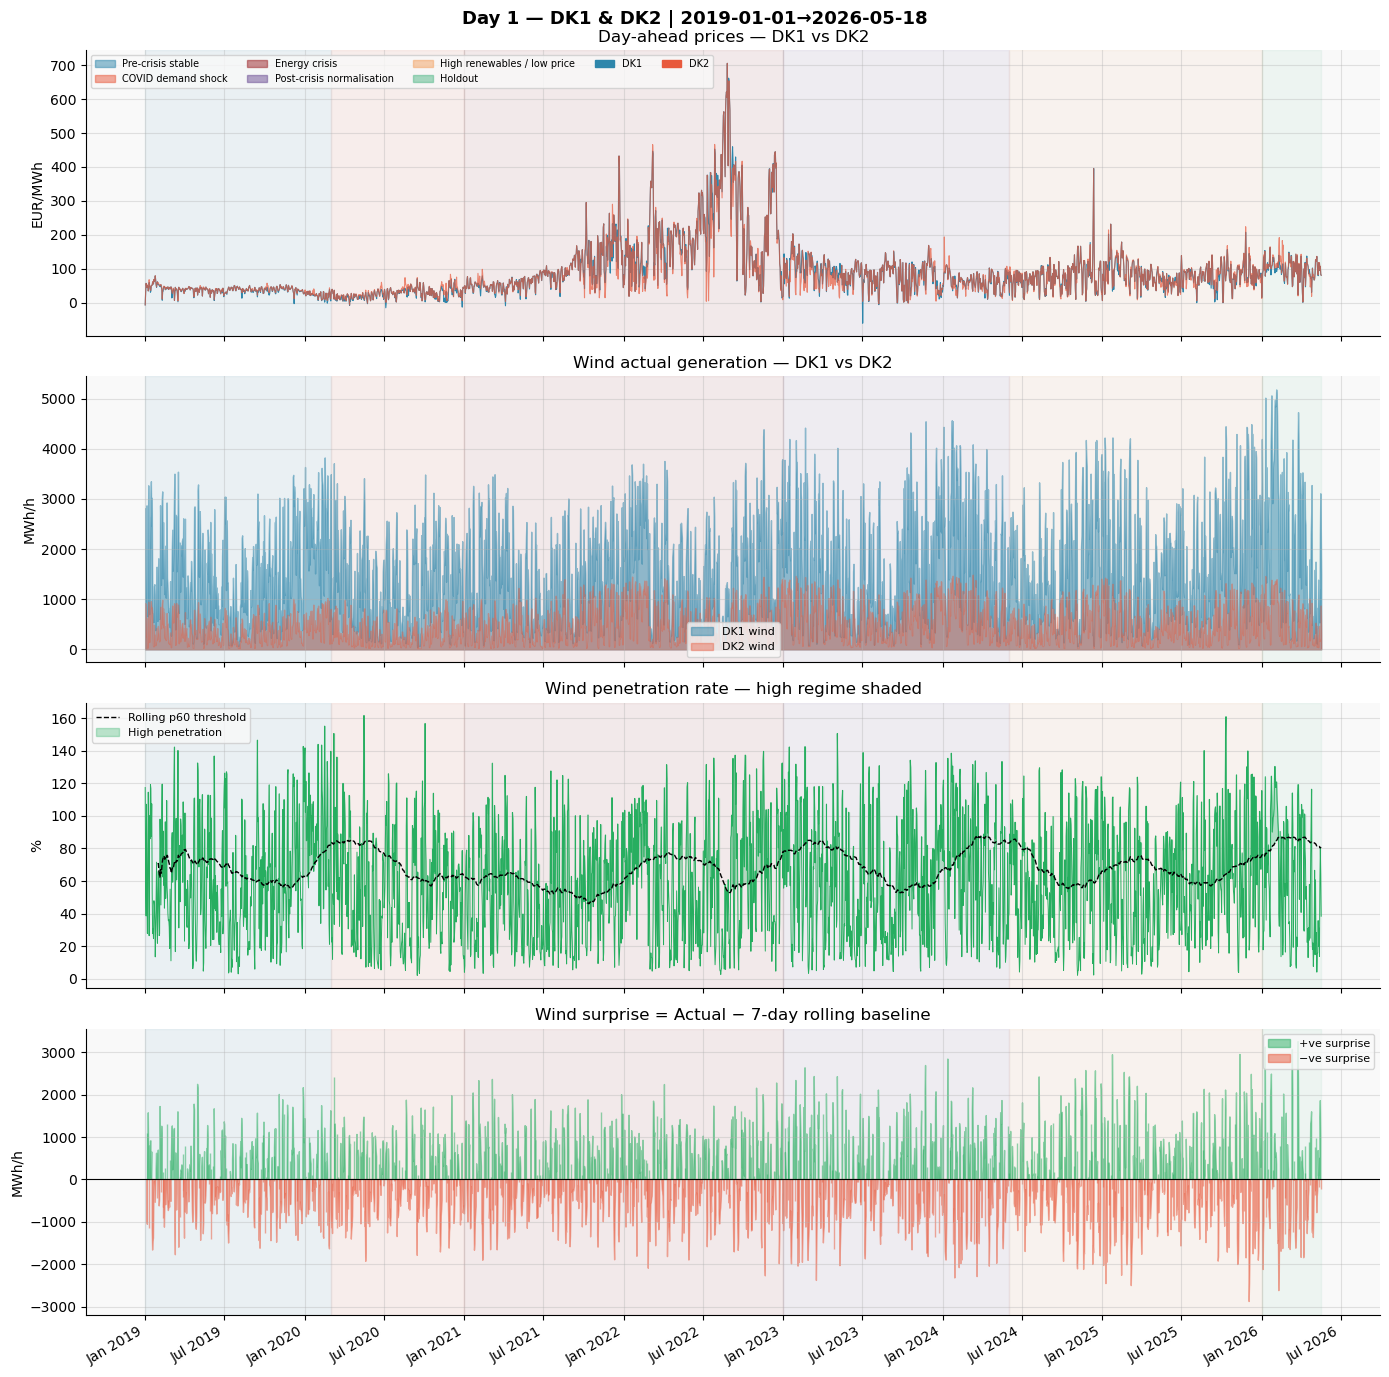

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# DAY 1 — DATA ACQUISITION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("  DAY 1: DATA ACQUISITION")
print("="*65)

df_dk1 = build_dataset(DK1, "DK1")
df_dk2 = build_dataset(DK2, "DK2")

df_wf      = df_dk1[df_dk1.index <  HOLDOUT_START].copy()
df_holdout = df_dk1[df_dk1.index >= HOLDOUT_START].copy()

# ── Day 1 plot ────────────────────────────────────────────────────────────────
regimes = [
    ("2019-01-01","2020-03-01","#2E86AB","Pre-crisis stable"),
    ("2020-03-01","2021-01-01","#E8593C","COVID demand shock"),
    ("2021-01-01","2023-01-01","#9B2226","Energy crisis"),
    ("2023-01-01","2024-06-01","#6A4C93","Post-crisis normalisation"),
    ("2024-06-01","2026-01-01","#F4A261","High renewables / low price"),
    ("2026-01-01","2099-01-01","#52B788","Holdout"),
]

def shade(ax, df_d):
    for rs, re, col, _ in regimes:
        rts = pd.Timestamp(rs, tz="UTC")
        rte = min(pd.Timestamp(re, tz="UTC"), df_d.index[-1])
        if rts < df_d.index[-1]:
            ax.axvspan(rts, rte, alpha=0.07, color=col)

df_d1 = df_dk1.resample("D").mean()
df_d2 = df_dk2.resample("D").mean()

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
fig.suptitle(f"Day 1 — DK1 & DK2 | {FULL_START}→{FULL_END}",
             fontsize=13, fontweight='bold')
for ax in axes:
    shade(ax, df_d1)

axes[0].plot(df_d1.index, df_d1['price'], color='#2E86AB', lw=0.8, label='DK1')
axes[0].plot(df_d2.index, df_d2['price'], color='#E8593C', lw=0.8, label='DK2', alpha=0.7)
axes[0].set(ylabel="EUR/MWh", title="Day-ahead prices — DK1 vs DK2")
axes[0].legend(handles=[mpatches.Patch(color=c, alpha=0.5, label=l)
               for _,_,c,l in regimes] +
               [mpatches.Patch(color='#2E86AB', label='DK1'),
                mpatches.Patch(color='#E8593C', label='DK2')],
               loc='upper left', fontsize=7, ncol=5)

axes[1].fill_between(df_d1.index, df_d1['wind_act'], alpha=0.5,
                     color='#2E86AB', label='DK1 wind')
axes[1].fill_between(df_d2.index, df_d2['wind_act'], alpha=0.4,
                     color='#E8593C', label='DK2 wind')
axes[1].set(ylabel="MWh/h", title="Wind actual generation — DK1 vs DK2")
axes[1].legend(fontsize=8)

if 'penetration' in df_d1.columns:
    axes[2].plot(df_d1.index, df_d1['penetration']*100, color='#27AE60', lw=0.7)
    p_thresh = df_dk1['penetration'].rolling(
        PENETRATION_WINDOW, min_periods=720).quantile(
        PENETRATION_PCT/100).resample("D").mean()
    axes[2].plot(df_d1.index, p_thresh*100, color='black', lw=1, ls='--',
                 label=f'Rolling p{PENETRATION_PCT} threshold')
    axes[2].fill_between(df_d1.index, df_d1['penetration']*100, p_thresh*100,
                         where=df_d1['penetration'] >= p_thresh,
                         alpha=0.3, color='#27AE60', label='High penetration')
    axes[2].set(ylabel="%", title="Wind penetration rate — high regime shaded")
    axes[2].legend(fontsize=8)

axes[3].fill_between(df_d1.index, df_d1['wind_surprise'], 0,
                     where=df_d1['wind_surprise'] >= 0, alpha=0.5,
                     color='#27AE60', label='+ve surprise')
axes[3].fill_between(df_d1.index, df_d1['wind_surprise'], 0,
                     where=df_d1['wind_surprise'] < 0, alpha=0.5,
                     color='#E8593C', label='−ve surprise')
axes[3].axhline(0, color='black', lw=0.8)
axes[3].set(ylabel="MWh/h",
            title="Wind surprise = Actual − 7-day rolling baseline")
axes[3].legend(fontsize=8)
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[3].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[3].xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# DAY 2 — WALK-FORWARD (DK1)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("  DAY 2: WALK-FORWARD ENGINE  (DK1)")
print("="*65)

windows     = make_windows(df_wf)
fold_res    = {s: [] for s in STRATEGIES}
model_stats = []
bench_res   = []

desc = {
    'all':         'No filter — baseline',
    'penetration': 'High wind penetration',
    'price':       'DK1 price above 6m median',
    'hc':          'Penetration high + price high  ← headline',
}

print(f"\n  {len(windows)} folds | {TRAIN_YEARS}yr train / {TEST_MONTHS}m test")
print(f"\n  {'#':>3}  {'α̂':>8}  {'γ̂':>8}  {'α̂_HC':>8}  "
      f"{'ADF-p':>6}  {'EG-p':>6}  {'HL':>5}  {'R²':>5}  "
      + "  ".join(f"{'SR-'+s[:3].upper():>7}" for s in STRATEGIES))
print("-" * 100)

for i, (ts, te, ps, pe) in enumerate(windows):
    df_tr = df_wf[(df_wf.index >= ts) & (df_wf.index < te)].copy()
    df_te = df_wf[(df_wf.index >= ps) & (df_wf.index < pe)].copy()
    if len(df_tr) < 500 or len(df_te) < 100:
        continue

    m   = fit_model(df_tr)
    row = {s: run_backtest(df_te, m['alpha'], m['gamma'], df_tr, s)
           for s in STRATEGIES}
    bm  = run_benchmarks(df_te)

    model_stats.append({**m, 'test_start': ps, 'test_end': pe, 'fold': i+1})
    bench_res.append(bm)

    for s in STRATEGIES:
        fold_res[s].append({
            'fold': i+1, 'train_start': ts, 'train_end': te,
            'test_start': ps, 'test_end': pe,
            **{k: row[s][k] for k in ['sharpe','sharpe_all',
                                       'total_pnl','win_rate','n_trades',
                                       'pct_active','pnl','cum_pnl','trade_log']},
        })

    srs = "  ".join(f"{row[s]['sharpe_all']:>7.2f}" for s in STRATEGIES)
    print(f"  {i+1:>3}  {m['alpha']:>8.4f}  {m['gamma']:>8.4f}  "
          f"{m['alpha_hc']:>8.4f}  {m['adf_p']:>6.4f}  {m['eg_p']:>6.4f}  "
          f"{m['halflife']:>5.1f}  {m['r2']:>5.3f}  {srs}")

print("-" * 100)


  DAY 2: WALK-FORWARD ENGINE  (DK1)

  9 folds | 2yr train / 6m test

    #        α̂        γ̂     α̂_HC   ADF-p    EG-p     HL     R²   SR-ALL   SR-PEN   SR-PRI    SR-HC
----------------------------------------------------------------------------------------------------
    1   -0.0071    0.0001    0.0015  0.0000  0.0000   10.5  0.182     3.27     1.13     2.26     0.47
    2   -0.0111    0.0028    0.0018  0.0000  0.0000   12.6  0.194     4.57     1.40     4.02     0.93
    3   -0.0148    0.0003    0.0056  0.0000  0.0001   28.6  0.067     2.00     0.91     1.07     0.14
    4   -0.0134   -0.0095   -0.0036  0.0001  0.0004   28.3  0.070     4.00     1.53     2.39     0.38
    5   -0.0523    0.0198   -0.0181  0.0000  0.0001   32.2  0.100     3.08     0.52     0.83     0.14
    6   -0.0601    0.0265   -0.0060  0.0000  0.0000   26.6  0.143     2.22     0.74     1.69     0.51
    7   -0.0666    0.0349    0.0142  0.0000  0.0001   28.1  0.168     2.55    -0.10     1.16     0.23
    8   -0.0

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# DAY 3 — RESULTS, EXTENSIONS & DK2 TEST
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("  DAY 3: RESULTS, EXTENSIONS & DK2 TEST")
print("="*65)

# ── Strategy comparison ───────────────────────────────────────────────────────
print(f"\n  Strategy comparison (all-hours Sharpe):")
print(f"  {'Strategy':<14}  {'Sharpe':>7}  {'WinRt':>6}  "
      f"{'Trades':>7}  {'%Time':>6}  Description")
print("-" * 72)

for s in STRATEGIES:
    folds = fold_res[s]
    if not folds: continue
    sr = np.nanmean(agg(folds, 'sharpe_all'))
    wr = np.nanmean(agg(folds, 'win_rate')) * 100
    tr = int(np.nansum(agg(folds, 'n_trades')))
    pa = np.nanmean(agg(folds, 'pct_active')) * 100
    print(f"  {s:<14}  {sr:>7.2f}  {wr:>5.1f}%  {tr:>7}  {pa:>5.1f}%  {desc[s]}")

bh_sr  = np.nanmean([b['bh_sharpe']  for b in bench_res])
mom_sr = np.nanmean([b['mom_sharpe'] for b in bench_res])
print("-" * 72)
print(f"  {'buy-and-hold':<14}  {bh_sr:>7.2f}  (passive benchmark — always long)")
print(f"  {'momentum':<14}  {mom_sr:>7.2f}  (hourly autocorrelation is real in power)")
# ── Regime-conditional α̂ ─────────────────────────────────────────────────────
print(f"\n  Regime-conditional α̂ (interaction model):")
print(f"  {'Fold':>4}  {'Period':>12}  {'α̂ base':>9}  "
      f"{'α̂+penetration':>14}  {'α̂+price':>10}  {'α̂ HC':>8}  Note")
print("-" * 75)
for m in model_stats:
    note = " ← gas crisis" if 2021 <= m['test_start'].year <= 2023 else \
           " ← post-crisis" if m['test_start'].year >= 2024 else ""
    print(f"  {m['fold']:>4}  {str(m['test_start'].date()):>12}  "
          f"{m['alpha0']:>9.4f}  "
          f"{m['alpha0']+m['alpha_pn']:>14.4f}  "
          f"{m['alpha0']+m['alpha_pr']:>10.4f}  "
          f"{m['alpha_hc']:>8.4f}{note}")
print("-" * 75)

alpha_hc_vals   = [m['alpha_hc'] for m in model_stats]
alpha_base_vals = [m['alpha0']   for m in model_stats]
mean_amp = np.mean([(h-b)/abs(b)*100 if b != 0 else 0
                    for h,b in zip(alpha_hc_vals, alpha_base_vals)])
amplified = mean_amp < 0
print(f"\n  HC vs base α̂: {mean_amp:+.0f}% "
      f"({'amplified — HC conditions strengthen merit-order' if amplified else 'dampened — see interpretation below'})")
if not amplified:
    print(f"  Note: positive % means HC α̂ is less negative than base.")
    print(f"  This can occur when high-penetration hours coincide with low-price")
    print(f"  periods (e.g. curtailment risk suppresses both signals). Check the")
    print(f"  correlation between pen_high and price_high in your data.")


  DAY 3: RESULTS, EXTENSIONS & DK2 TEST

  Strategy comparison (all-hours Sharpe):
  Strategy         Sharpe   WinRt   Trades   %Time  Description
------------------------------------------------------------------------
  all                3.23   57.6%      562   16.4%  No filter — baseline
  penetration        0.88   54.7%      180    6.9%  High wind penetration
  price              1.98   65.1%      348    9.9%  DK1 price above 6m median
  hc                 0.48   63.5%      106    3.6%  Penetration high + price high  ← headline
------------------------------------------------------------------------
  buy-and-hold      -8.40  (passive benchmark — always long)
  momentum          26.88  (hourly autocorrelation is real in power)

  Regime-conditional α̂ (interaction model):
  Fold        Period    α̂ base  α̂+penetration    α̂+price     α̂ HC  Note
---------------------------------------------------------------------------
     1    2021-01-01    -0.0063         -0.0072      0.0024

In [9]:
# ── Trade log ─────────────────────────────────────────────────────────────────
all_trades = pd.concat([f['trade_log'] for f in fold_res['hc']
                        if len(f['trade_log']) > 0], ignore_index=True)
if len(all_trades) > 0:
    print(f"\n  Trade log — HC strategy ({len(all_trades)} trades):")
    print(f"  Avg hold: {all_trades['hold_hours'].mean():.1f}h  |  "
          f"Median: {all_trades['hold_hours'].median():.0f}h  |  "
          f"Win rate: {(all_trades['pnl']>0).mean()*100:.1f}%")
    seasonal = all_trades.groupby('entry_month')['pnl'].agg(['mean','count'])
    months   = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
    print(f"\n  Seasonal breakdown:")
    for mo, row in seasonal.iterrows():
        bar  = '█' * min(int(abs(row['mean']) / 15), 20)
        sign = '+' if row['mean'] >= 0 else '-'
        print(f"    {months[mo]:>3}: {sign}{abs(row['mean']):>5.0f} EUR/MW  "
              f"{bar}  ({int(row['count'])} trades)")


  Trade log — HC strategy (106 trades):
  Avg hold: 13.5h  |  Median: 8h  |  Win rate: 77.4%

  Seasonal breakdown:
    Jan: +    6 EUR/MW    (7 trades)
    Feb: +   21 EUR/MW  █  (3 trades)
    Mar: +   46 EUR/MW  ███  (6 trades)
    Apr: +   18 EUR/MW  █  (6 trades)
    May: +   61 EUR/MW  ████  (4 trades)
    Jun: +   25 EUR/MW  █  (12 trades)
    Jul: +   49 EUR/MW  ███  (8 trades)
    Aug: +   10 EUR/MW    (12 trades)
    Sep: +   26 EUR/MW  █  (13 trades)
    Oct: +   29 EUR/MW  █  (18 trades)
    Nov: +   25 EUR/MW  █  (12 trades)
    Dec: +   57 EUR/MW  ███  (5 trades)


In [10]:
# ── Cost sensitivity ──────────────────────────────────────────────────────────
# Pre-slice all train/test windows once to avoid index misalignment in the loop
window_slices = []
for ts, te, ps, pe in windows:
    df_tr = df_wf[(df_wf.index >= ts) & (df_wf.index < te)].copy()
    df_te = df_wf[(df_wf.index >= ps) & (df_wf.index < pe)].copy()
    window_slices.append((df_tr, df_te))

print(f"\n  Cost sensitivity — HC strategy:")
print(f"  {'Hold cost':>10}  {'Sharpe':>7}  {'Win rate':>8}  Status")
print("-" * 42)
for hc_cost in COST_SWEEP:
    sharpes, wrs = [], []
    for i, (df_tr, df_te) in enumerate(window_slices):
        if i >= len(model_stats): continue
        if len(df_tr) < 500 or len(df_te) < 100: continue
        r = run_backtest(df_te, model_stats[i]['alpha'], model_stats[i]['gamma'],
                         df_tr, 'hc', hold_cost=hc_cost)
        sharpes.append(r['sharpe_all'])
        if not np.isnan(r['win_rate']):
            wrs.append(r['win_rate'])
    sr = np.nanmean(sharpes)
    wr = np.nanmean(wrs) * 100 if wrs else np.nan
    ok = "✓" if sr > 0 else "✗"
    arrow = " ← baseline" if hc_cost == HOLD_COST else ""
    print(f"  {hc_cost:>10.1f}  {sr:>7.2f}  {wr:>7.1f}%  {ok}{arrow}")


  Cost sensitivity — HC strategy:
   Hold cost   Sharpe  Win rate  Status
------------------------------------------
         0.0     0.70     69.1%  ✓
         0.5     0.63     68.2%  ✓
         1.0     0.55     65.5%  ✓
         1.5     0.48     63.5%  ✓ ← baseline
         2.0     0.41     62.2%  ✓
         2.5     0.33     60.5%  ✓
         3.0     0.26     58.4%  ✓


In [11]:
# ── Final holdout ─────────────────────────────────────────────────────────────
holdout_res = None
if len(df_holdout) > 0 and fold_res['hc']:
    last     = fold_res['hc'][-1]
    last_m   = model_stats[-1]   # model params live here, not in fold_res
    ctx      = df_wf[df_wf.index >= last['train_start']].copy()
    holdout_res = run_backtest(df_holdout, last_m['alpha'], last_m['gamma'],
                               ctx, regime='hc')
    h = holdout_res
    print(f"\n  FINAL HOLDOUT DK1 ({HOLDOUT_START}→{FULL_END}) — 'hc'")
    print(f"  Sharpe {h['sharpe_all']:+.2f}  |  WR {h['win_rate']*100:.1f}%  "
          f"|  P&L {h['total_pnl']:+,.0f} EUR/MW  |  {h['n_trades']} trades")
    if h['n_trades'] < 20:
        print(f"  ⚠ Only {h['n_trades']} trades — interpret cautiously")


  FINAL HOLDOUT DK1 (2026-01-01→2026-05-18) — 'hc'
  Sharpe +0.61  |  WR 55.1%  |  P&L +185 EUR/MW  |  7 trades
  ⚠ Only 7 trades — interpret cautiously


In [12]:
# ── DK2 out-of-sample test ────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  DK2 OUT-OF-SAMPLE TEST")
print(f"  Frozen DK1 α̂ and γ̂ applied to DK2 — parameters NOT re-estimated")
print(f"{'='*65}")

last_alpha = model_stats[-1]['alpha']
last_gamma = model_stats[-1]['gamma']
dk2_wf     = df_dk2[df_dk2.index < HOLDOUT_START].copy()
dk2_folds  = {s: [] for s in STRATEGIES}
dk2_wins   = make_windows(dk2_wf)

print(f"\n  {'#':>3}  {'Period':>12}  "
      + "  ".join(f"{'SR-'+s[:3].upper():>7}" for s in STRATEGIES))
print("-" * 55)

for i, (ts, te, ps, pe) in enumerate(dk2_wins):
    df_tr = dk2_wf[(dk2_wf.index >= ts) & (dk2_wf.index < te)].copy()
    df_te = dk2_wf[(dk2_wf.index >= ps) & (dk2_wf.index < pe)].copy()
    if len(df_tr) < 500 or len(df_te) < 100: continue
    row = {s: run_backtest(df_te, last_alpha, last_gamma, df_tr, s)
           for s in STRATEGIES}
    for s in STRATEGIES:
        dk2_folds[s].append({**{k: row[s][k] for k in
                                ['sharpe_all','win_rate','n_trades','pnl']}})
    srs = "  ".join(f"{row[s]['sharpe_all']:>7.2f}" for s in STRATEGIES)
    print(f"  {i+1:>3}  {str(ps.date()):>12}  {srs}")

print("-" * 55)
print(f"\n  {'Strategy':<14}  {'DK1 SR':>7}  {'DK2 SR':>7}  {'Diff':>7}  Interpretation")
print("-" * 65)
for s in STRATEGIES:
    dk1_sr = np.nanmean(agg(fold_res[s],  'sharpe_all'))
    dk2_sr = np.nanmean(agg(dk2_folds[s], 'sharpe_all'))
    diff   = dk2_sr - dk1_sr
    note   = "transfers" if dk2_sr > 0 else "no transfer"
    print(f"  {s:<14}  {dk1_sr:>7.2f}  {dk2_sr:>7.2f}  {diff:>+7.2f}  {note}")

dk2_hc_sr = np.nanmean(agg(dk2_folds['hc'], 'sharpe_all'))
dk1_hc_sr = np.nanmean(agg(fold_res['hc'],  'sharpe_all'))
print(f"\n  INTERPRETATION:")
if dk2_hc_sr > 0:
    print(f"  HC signal transfers to DK2 (SR={dk2_hc_sr:.2f} vs DK1 {dk1_hc_sr:.2f})")
    print(f"  Weaker in DK2: Swedish hydro absorbs wind intermittency flexibly,")
    print(f"  reducing the spread signal compared to German gas/coal in DK1.")
    print(f"  → Pan-Nordic merit-order finding.")
else:
    print(f"  HC signal does not transfer to DK2 (SR={dk2_hc_sr:.2f} vs DK1 {dk1_hc_sr:.2f})")
    print(f"  DK2's hydro-dominated neighbours buffer intermittency through")
    print(f"  reservoir dispatch. The penetration + price regime that defines")
    print(f"  'congestion' in DK1 does not create the same local price pressure")
    print(f"  in DK2. → DK1-specific market microstructure confirmed.")


  DK2 OUT-OF-SAMPLE TEST
  Frozen DK1 α̂ and γ̂ applied to DK2 — parameters NOT re-estimated

    #        Period   SR-ALL   SR-PEN   SR-PRI    SR-HC
-------------------------------------------------------
    1    2021-01-01     2.67     1.26     1.94     0.81
    2    2021-07-01     4.01     1.90     3.56     1.54
    3    2022-01-01     1.51     0.85     0.52     0.14
    4    2022-07-01     3.73     1.95     2.15     0.93
    5    2023-01-01     3.89     0.42     2.20     0.04
    6    2023-07-01     3.27     1.05     2.33     0.41
    7    2024-01-01     3.91     0.89     3.10     0.42
    8    2024-07-01     2.76     0.88     2.59     0.88
    9    2025-01-01     3.80     1.04     2.35     0.67
-------------------------------------------------------

  Strategy         DK1 SR   DK2 SR     Diff  Interpretation
-----------------------------------------------------------------
  all                3.23     3.28    +0.05  transfers
  penetration        0.88     1.14    +0.26  transf

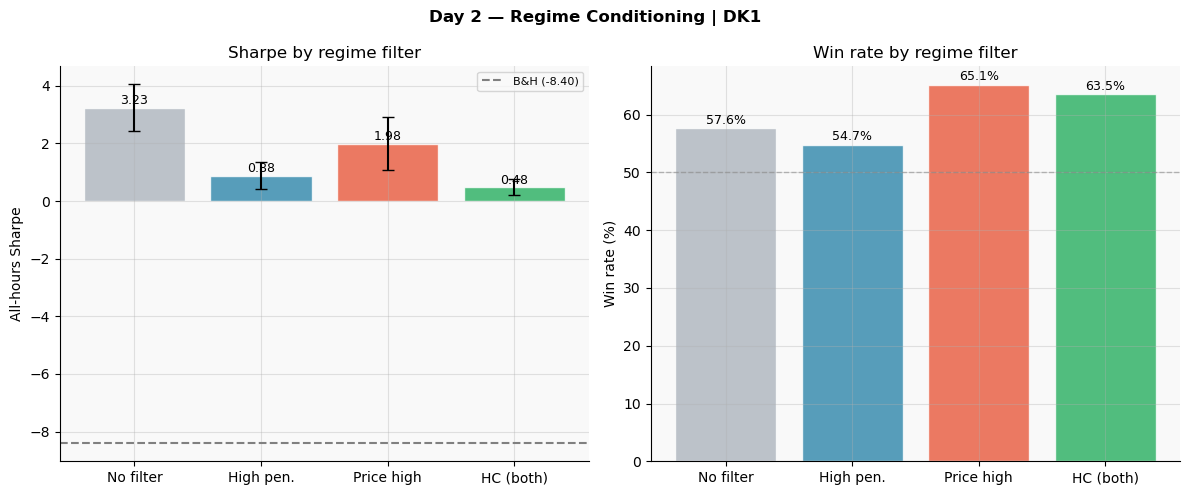

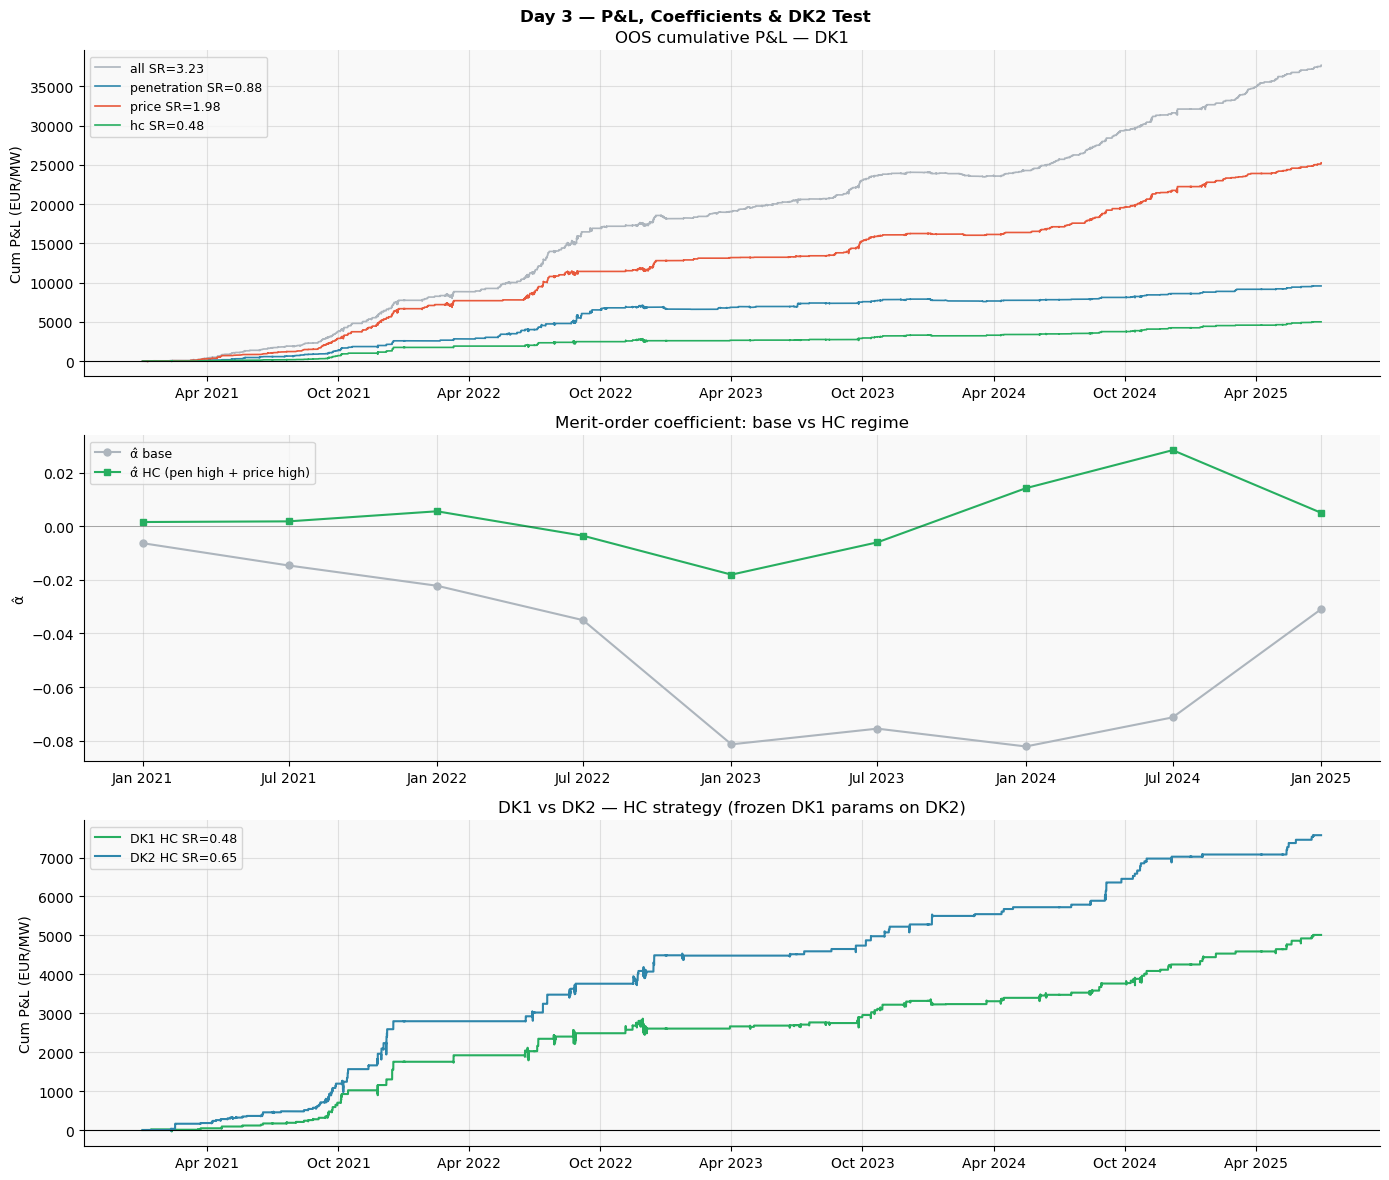

In [13]:
# ── Plots ─────────────────────────────────────────────────────────────────────
colors = {'all':'#ADB5BD','penetration':'#2E86AB','price':'#E8593C','hc':'#27AE60'}
xlbls  = ['No filter','High pen.','Price high','HC (both)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Day 2 — Regime Conditioning | DK1", fontsize=12, fontweight='bold')

sr_m = [np.nanmean(agg(fold_res[s], 'sharpe_all')) for s in STRATEGIES]
sr_s = [np.nanstd(agg(fold_res[s],  'sharpe_all')) for s in STRATEGIES]
wr_m = [np.nanmean(agg(fold_res[s], 'win_rate'))*100 for s in STRATEGIES]
bc   = [colors[s] for s in STRATEGIES]

bars = axes[0].bar(xlbls, sr_m, color=bc, alpha=0.8,
                   edgecolor='white', yerr=sr_s, capsize=4)
axes[0].axhline(bh_sr,  color='gray',  lw=1.5, ls='--',
                label=f'B&H ({bh_sr:.2f})')
axes[0].set(ylabel="All-hours Sharpe", title="Sharpe by regime filter")
axes[0].legend(fontsize=8)
for bar, v in zip(bars, sr_m):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f"{v:.2f}", ha='center', va='bottom', fontsize=9)

bars2 = axes[1].bar(xlbls, wr_m, color=bc, alpha=0.8, edgecolor='white')
axes[1].axhline(50, color='gray', lw=1, ls='--', alpha=0.5)
axes[1].set(ylabel="Win rate (%)", title="Win rate by regime filter")
for bar, v in zip(bars2, wr_m):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{v:.1f}%", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Day 3 — P&L, Coefficients & DK2 Test",
             fontsize=12, fontweight='bold')

for s, col in colors.items():
    pnls = pd.concat([f['pnl'] for f in fold_res[s]]).sort_index()
    pnls = pnls[~pnls.index.duplicated(keep='first')].cumsum().astype(float)
    sr_  = np.nanmean(agg(fold_res[s], 'sharpe_all'))
    axes[0].plot(pnls.index, pnls.values, color=col, lw=1.2,
                 label=f"{s} SR={sr_:.2f}")
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set(ylabel="Cum P&L (EUR/MW)", title="OOS cumulative P&L — DK1")
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))

dates      = [m['test_start'] for m in model_stats]
alpha_base = [m['alpha0']     for m in model_stats]
alpha_hc_l = [m['alpha_hc']   for m in model_stats]
axes[1].plot(dates, alpha_base, 'o-', color='#ADB5BD', lw=1.5, ms=5,
             label='α̂ base')
axes[1].plot(dates, alpha_hc_l, 's-', color='#27AE60', lw=1.5, ms=5,
             label='α̂ HC (pen high + price high)')
axes[1].axhline(0, color='black', lw=0.6, alpha=0.3)
axes[1].set(ylabel="α̂", title="Merit-order coefficient: base vs HC regime")
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

for fres, col, lbl in [
    (fold_res,  '#27AE60', f'DK1 HC SR={dk1_hc_sr:.2f}'),
    (dk2_folds, '#2E86AB', f'DK2 HC SR={dk2_hc_sr:.2f}'),
]:
    pnls = pd.concat([f['pnl'] for f in fres['hc']]).sort_index()
    pnls = pnls[~pnls.index.duplicated(keep='first')].cumsum().astype(float)
    axes[2].plot(pnls.index, pnls.values, color=col, lw=1.5, label=lbl)
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set(ylabel="Cum P&L (EUR/MW)",
            title="DK1 vs DK2 — HC strategy (frozen DK1 params on DK2)")
axes[2].legend(fontsize=9)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.tight_layout()
plt.show()

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
def fmt(folds, key): return f"{np.nanmean(agg(folds, key)):.2f}"
def fmtwr(folds):    return f"{np.nanmean(agg(folds,'win_rate'))*100:.1f}%"

h  = holdout_res
hc = fold_res['hc']

print(f"""
{'='*70}
  FINAL RESULTS 
{'='*70}

  DATA
  ────
  ENTSO-E: day-ahead prices, wind actual (B18 offshore + B19 onshore)
  EDS: gross consumption (penetration regime) + post-Oct 2025 prices
  DK1: {FULL_START} → {FULL_END}  ({len(df_dk1):,} hourly obs, 6 market regimes)
  DK2: {FULL_START} → {FULL_END}  ({len(df_dk2):,} hourly obs, OOS test)

  MODEL
  ─────
  Base:        P_t = β₀ + α·W_actual + γ·W_surprise + ε_t
  Interaction: P_t = β₀ + α₀·W + α₁·(W×penetration) + α₂·(W×price_high) + ε_t
  W_surprise = W_actual − 7-day rolling seasonal mean
  Costs: {ENTRY_COST}+{EXIT_COST} EUR/MWh round-trip + {HOLD_COST} EUR/MWh/hr holding

  WALK-FORWARD  ({len(windows)} folds, all-hours Sharpe)
  ─────────────────────────────────────────────────────
  No filter:      SR={fmt(fold_res['all'],'sharpe_all')}   WR={fmtwr(fold_res['all'])}   {int(np.nansum(agg(fold_res['all'],'n_trades')))} trades
  High pen.:      SR={fmt(fold_res['penetration'],'sharpe_all')}   WR={fmtwr(fold_res['penetration'])}   {int(np.nansum(agg(fold_res['penetration'],'n_trades')))} trades
  Price high:     SR={fmt(fold_res['price'],'sharpe_all')}   WR={fmtwr(fold_res['price'])}   {int(np.nansum(agg(fold_res['price'],'n_trades')))} trades
  HC (both):      SR={fmt(hc,'sharpe_all')}   WR={fmtwr(hc)}   {int(np.nansum(agg(hc,'n_trades')))} trades  ← headline
  Buy-and-hold:   SR={bh_sr:.2f}  (passive benchmark)
  Momentum:       SR={mom_sr:.2f}  (hourly autocorrelation — real in power mkts)

  REGIME-CONDITIONAL α̂
  ─────────────────────
  HC vs base: {mean_amp:+.0f}% ({'amplified' if amplified else 'dampened'})
  High penetration + high price → wind has
  {'stronger' if amplified else 'different'} price impact than unconditional model

  DK2 OUT-OF-SAMPLE
  ──────────────────
  HC DK2 SR={dk2_hc_sr:.2f}  vs  DK1 SR={dk1_hc_sr:.2f}
  {'→ Pan-Danish signal' if dk2_hc_sr > 0 else '→ DK1-specific microstructure'}

  FINAL HOLDOUT ({HOLDOUT_START} → {FULL_END})
  ──────────────────────────────────────────────
  {f"SR={h['sharpe_all']:+.2f} | WR={h['win_rate']*100:.0f}% | P&L={h['total_pnl']:+,.0f} EUR/MW | {h['n_trades']} trades" if h else "N/A"}

{'='*70}
""")


  FINAL RESULTS 

  DATA
  ────
  ENTSO-E: day-ahead prices, wind actual (B18 offshore + B19 onshore)
  EDS: gross consumption (penetration regime) + post-Oct 2025 prices
  DK1: 2019-01-01 → 2026-05-18  (64,654 hourly obs, 6 market regimes)
  DK2: 2019-01-01 → 2026-05-18  (64,654 hourly obs, OOS test)

  MODEL
  ─────
  Base:        P_t = β₀ + α·W_actual + γ·W_surprise + ε_t
  Interaction: P_t = β₀ + α₀·W + α₁·(W×penetration) + α₂·(W×price_high) + ε_t
  W_surprise = W_actual − 7-day rolling seasonal mean
  Costs: 1.0+1.0 EUR/MWh round-trip + 1.5 EUR/MWh/hr holding

  WALK-FORWARD  (9 folds, all-hours Sharpe)
  ─────────────────────────────────────────────────────
  No filter:      SR=3.23   WR=57.6%   562 trades
  High pen.:      SR=0.88   WR=54.7%   180 trades
  Price high:     SR=1.98   WR=65.1%   348 trades
  HC (both):      SR=0.48   WR=63.5%   106 trades  ← headline
  Buy-and-hold:   SR=-8.40  (passive benchmark)
  Momentum:       SR=26.88  (hourly autocorrelation — real in power